STEP 1: Loading Dataset...
 - Data Shape: (1797, 64) (64 Features per Image)

STEP 2: Preprocessing (Standard Scaling)...

STEP 3: Analyzing Explained Variance...


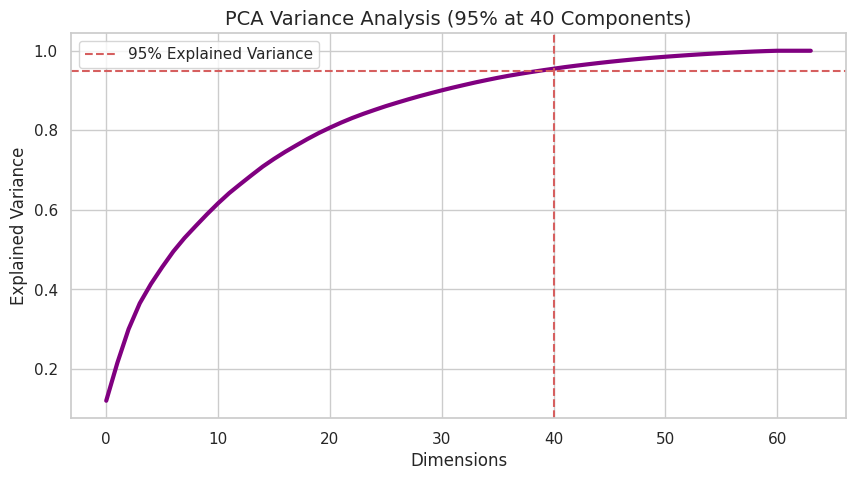

 - To keep 95% of information, we need 40 dimensions (down from 64).

STEP 4: Model Comparison (Original vs. PCA)...
 [Original 64D] Accuracy: 0.9722 | Time: 0.4715s
 [PCA Reduced 40D] Accuracy: 0.9528 | Time: 0.4815s
 🚀 PCA Training Speedup: -2.1%
 📉 Accuracy Drop: 1.94% (Trade-off)

STEP 5: Visualizing 2D Projection...


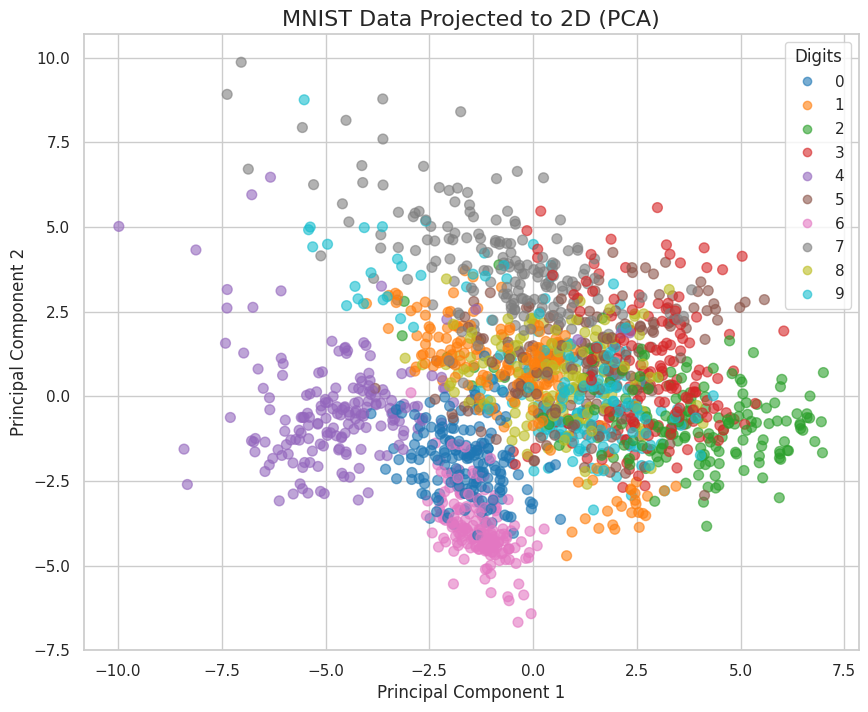


STEP 6: Visualizing Compression Quality...


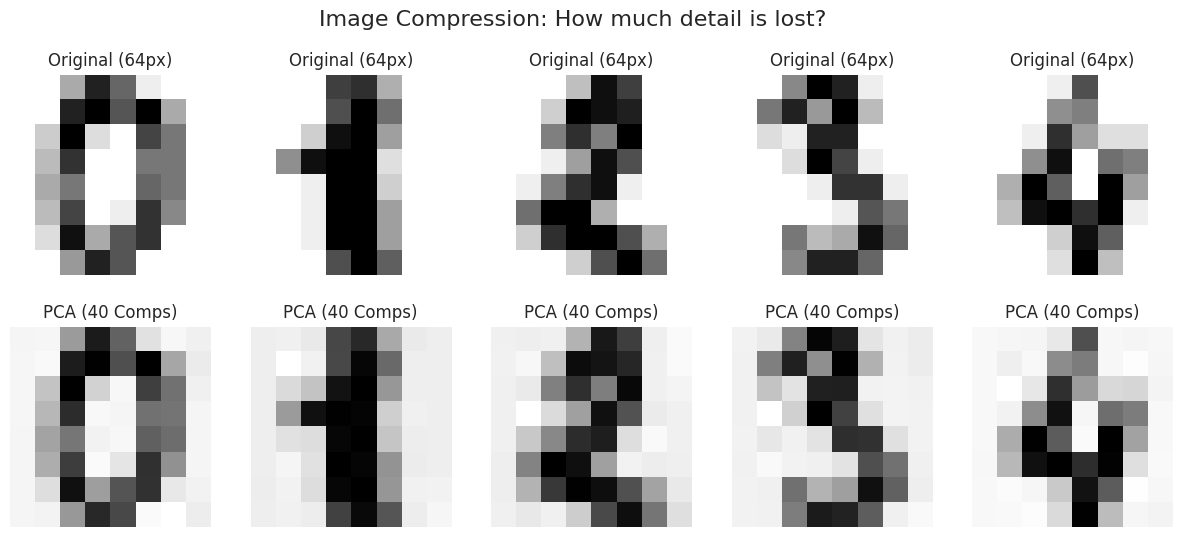

In [1]:
# PCA – Dimensionality Reduction
# Dataset: Scikit-Learn Digits (MNIST-like)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# SETTING PROFESSIONAL VISUALIZATION THEME
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

def load_data():
    """
    Loads the Digits dataset (1797 images, 8x8 pixels = 64 dimensions).
    """
    print("STEP 1: Loading Dataset...")
    digits = load_digits()
    X = digits.data
    y = digits.target
    print(f" - Data Shape: {X.shape} (64 Features per Image)")
    return X, y, digits.images

def preprocess_data(X):
    """
    Scales features. PCA is very sensitive to scale (variance).
    """
    print("\nSTEP 2: Preprocessing (Standard Scaling)...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

def analyze_variance(X_scaled):
    """
    Plots the Cumulative Explained Variance to find the optimal components.
    """
    print("\nSTEP 3: Analyzing Explained Variance...")

    pca = PCA()
    pca.fit(X_scaled)

    cumsum = np.cumsum(pca.explained_variance_ratio_)

    # Find components needed for 95% variance
    d_95 = np.argmax(cumsum >= 0.95) + 1

    plt.figure(figsize=(10, 5))
    plt.plot(cumsum, linewidth=3, color='purple')
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
    plt.axvline(x=d_95, color='r', linestyle='--')
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"PCA Variance Analysis (95% at {d_95} Components)", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f" - To keep 95% of information, we need {d_95} dimensions (down from 64).")
    return d_95

def compare_models(X_scaled, y, optimal_components):
    """
    Trains Logistic Regression on Original vs. Reduced data.
    """
    print("\nSTEP 4: Model Comparison (Original vs. PCA)...")

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    # --- MODEL 1: ORIGINAL (64 Features) ---
    start = time.time()
    clf_orig = LogisticRegression(max_iter=1000, random_state=42)
    clf_orig.fit(X_train, y_train)
    end = time.time()

    acc_orig = accuracy_score(y_test, clf_orig.predict(X_test))
    time_orig = end - start
    print(f" [Original 64D] Accuracy: {acc_orig:.4f} | Time: {time_orig:.4f}s")

    # --- MODEL 2: PCA REDUCED (Optimal Features) ---
    pca = PCA(n_components=optimal_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    start = time.time()
    clf_pca = LogisticRegression(max_iter=1000, random_state=42)
    clf_pca.fit(X_train_pca, y_train)
    end = time.time()

    acc_pca = accuracy_score(y_test, clf_pca.predict(X_test_pca))
    time_pca = end - start
    print(f" [PCA Reduced {optimal_components}D] Accuracy: {acc_pca:.4f} | Time: {time_pca:.4f}s")

    # Efficiency Check
    speedup = (time_orig - time_pca) / time_pca * 100 if time_pca > 0 else 0
    drop = (acc_orig - acc_pca) * 100
    print(f" 🚀 PCA Training Speedup: {speedup:.1f}%")
    print(f" 📉 Accuracy Drop: {drop:.2f}% (Trade-off)")

def visualize_2d_projection(X_scaled, y):
    """
    Projects data to 2D to visualize class separation.
    """
    print("\nSTEP 5: Visualizing 2D Projection...")

    pca_2d = PCA(n_components=2)
    X_2d = pca_2d.fit_transform(X_scaled)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.6, s=50)
    plt.legend(*scatter.legend_elements(), title="Digits")
    plt.title("MNIST Data Projected to 2D (PCA)", fontsize=16)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.show()

def visualize_reconstruction(X, optimal_components):
    """
    Shows Original Image vs. PCA Compressed Image.
    """
    print("\nSTEP 6: Visualizing Compression Quality...")

    # Fit PCA
    pca = PCA(n_components=optimal_components)
    X_reduced = pca.fit_transform(X)
    X_recovered = pca.inverse_transform(X_reduced)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    # Plot Original
    for i in range(5):
        axes[0, i].imshow(X[i].reshape(8, 8), cmap='gray_r')
        axes[0, i].set_title("Original (64px)")
        axes[0, i].axis('off')

    # Plot Compressed
    for i in range(5):
        axes[1, i].imshow(X_recovered[i].reshape(8, 8), cmap='gray_r')
        axes[1, i].set_title(f"PCA ({optimal_components} Comps)")
        axes[1, i].axis('off')

    plt.suptitle("Image Compression: How much detail is lost?", fontsize=16)
    plt.show()

# EXECUTION
if __name__ == "__main__":
    # 1. Load
    X_raw, y_raw, images = load_data()

    # 2. Scale
    X_std = preprocess_data(X_raw)

    # 3. Analyze Variance (Elbow)
    best_n = analyze_variance(X_std)

    # 4. Compare Models
    compare_models(X_std, y_raw, best_n)

    # 5. 2D Scatter
    visualize_2d_projection(X_std, y_raw)

    # 6. Reconstruction Demo
    visualize_reconstruction(X_raw, best_n)